In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# تحميل الداتا
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocessing
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 784)
X_test shape: (10000, 784)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Model A
model_A = Sequential([
    # Input + Hidden Layer 1
    Dense(256, activation='relu', input_shape=(784,)),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Output Layer
    Dense(10, activation='softmax')
])

model_A.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_A.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_A = model_A.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8909 - loss: 0.3652 - val_accuracy: 0.9602 - val_loss: 0.1337
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9507 - loss: 0.1632 - val_accuracy: 0.9668 - val_loss: 0.1096
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9615 - loss: 0.1262 - val_accuracy: 0.9695 - val_loss: 0.0968
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9679 - loss: 0.1043 - val_accuracy: 0.9734 - val_loss: 0.0898
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9711 - loss: 0.0907 - val_accuracy: 0.9738 - val_loss: 0.0865
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9746 - loss: 0.0788 - val_accuracy: 0.9766 - val_loss: 0.0819
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9775 - loss: 0.0693 - val_accuracy: 0.9775 - val_loss: 0.0815
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9803 - loss: 0.0630 - val_accuracy: 0.

In [ ]:
# Model B
model_B = Sequential([
    Dense(256, activation='tanh', input_shape=(784,)),
    Dropout(0.3),
    Dense(128, activation='tanh'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model_B.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_B = model_B.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8842 - loss: 0.3826 - val_accuracy: 0.9390 - val_loss: 0.2085
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9304 - loss: 0.2337 - val_accuracy: 0.9539 - val_loss: 0.1631
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9420 - loss: 0.1888 - val_accuracy: 0.9601 - val_loss: 0.1388
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9500 - loss: 0.1631 - val_accuracy: 0.9627 - val_loss: 0.1265
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9570 - loss: 0.1425 - val_accuracy: 0.9658 - val_loss: 0.1143
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9590 - loss: 0.1297 - val_accuracy: 0.9675 - val_loss: 0.1102
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9645 - loss: 0.1147 - val_accuracy: 0.9697 - val_loss: 0.1015
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9665 - loss: 0.1058 - val_accuracy: 0.

Model A (ReLU) - Accuracy: 98.22% | Loss: 0.0621
Model B (Tanh) - Accuracy: 97.46% | Loss: 0.0784


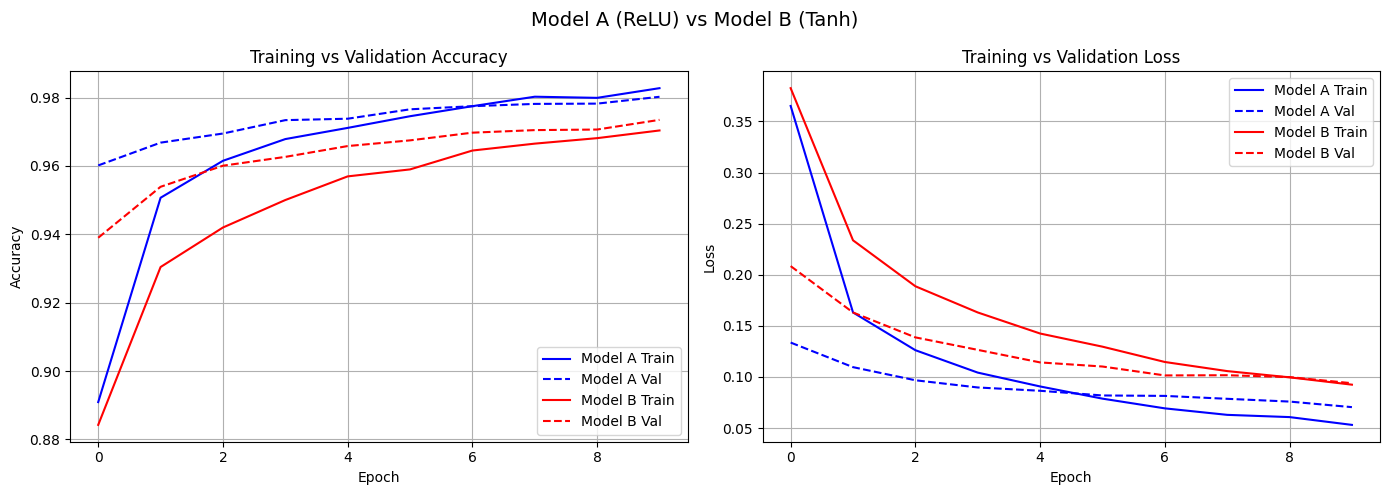

In [ ]:
# Evaluation
loss_A, acc_A = model_A.evaluate(X_test, y_test, verbose=0)
loss_B, acc_B = model_B.evaluate(X_test, y_test, verbose=0)

print("=" * 45)
print(f"Model A (ReLU) - Accuracy: {acc_A*100:.2f}% | Loss: {loss_A:.4f}")
print(f"Model B (Tanh) - Accuracy: {acc_B*100:.2f}% | Loss: {loss_B:.4f}")
print("=" * 45)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_A.history['accuracy'], label='Model A Train', color='blue')
axes[0].plot(history_A.history['val_accuracy'], label='Model A Val', color='blue', linestyle='--')
axes[0].plot(history_B.history['accuracy'], label='Model B Train', color='red')
axes[0].plot(history_B.history['val_accuracy'], label='Model B Val', color='red', linestyle='--')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_A.history['loss'], label='Model A Train', color='blue')
axes[1].plot(history_A.history['val_loss'], label='Model A Val', color='blue', linestyle='--')
axes[1].plot(history_B.history['loss'], label='Model B Train', color='red')
axes[1].plot(history_B.history['val_loss'], label='Model B Val', color='red', linestyle='--')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Model A (ReLU) vs Model B (Tanh)', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()